In [26]:
import glob
import pandas as pd

# calculate average percent human in longitudinal samples
# load all preprocessing logs
log_read_counts = {}

# load longitudinal sample readpreprocessing logs
for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/projects/cf_phageome_analyses/longitudinal_phageomes/results/readpreprocessing/*_run2/.command.log'):
    sample = file.rpartition('/')[0].rpartition('/')[2].split('.')[0]
    group = file.rpartition('/')[0].rpartition('/')[2].split('.')[0][0:3]
    raw_read_line = False
    for line in open(file, 'rt').readlines():
        if '"reads_out":' in line:
            hostile_read_count = int(line.strip().split(': ')[1].split(',')[0])/2
        if raw_read_line:
            raw_read_count = line.strip().split(': ')[1]
            raw_read_line = False
        if 'Read1 before filtering:' in line:
            raw_read_line = True
    log_read_counts[sample] = {'Group': group, 'Raw': raw_read_count, 'Human removed': hostile_read_count}

# make df from read counts
read_count_df = pd.DataFrame.from_dict(log_read_counts, orient='index')
read_count_df['sample'] = read_count_df.index
read_count_df['Raw'] = read_count_df['Raw'].astype(int)
read_count_df['Human removed'] = read_count_df['Human removed'].astype(int)
read_count_df['perc_human'] = 100 - (read_count_df['Human removed']/read_count_df['Raw'])*100
read_count_df[read_count_df.index.str.startswith('L')]['perc_human'].mean()

np.float64(98.32282950781159)

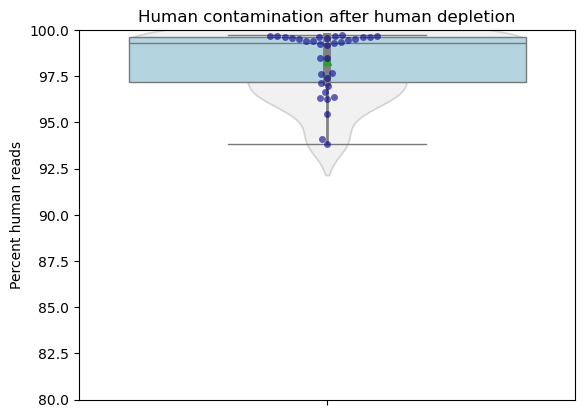

In [28]:
# Create a boxplot of percent human reads
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=read_count_df, y='perc_human', color='lightblue', showmeans=True)
sns.swarmplot(data=read_count_df, y='perc_human', color='darkblue', alpha=0.6)
sns.violinplot(data=read_count_df, y='perc_human', color='lightgrey', alpha=0.3)
plt.ylabel('Percent human reads')
plt.title('Human contamination after human depletion')
plt.ylim(80, 100)
plt.show()